# Econ 521 — Lab 3
## Randomized Controlled Trials II: Precision, Replication, and Honest Inference

Last week we took a real experiment apart and estimated its effect with the right standard errors.
Thursday's lecture asked the next question: **when should anyone believe the number?** Results can
fail to replicate. Null results end up in file drawers. Researchers can try many analyses and report
the one that worked, which is exactly what pre-analysis plans are meant to prevent. Today we look at
each of these problems from the analyst's side, in code.

**Running examples.**

- **Thornton (2008)**, "The Demand for, and Impact of, Learning HIV Status," *American Economic
  Review*. The cash-incentive experiment from Lab 2. Used in §1 and §6.
- **Bertrand and Mullainathan (2004)**, "Are Emily and Greg More Employable than Lakisha and Jamal?
  A Field Experiment on Labor Market Discrimination," *American Economic Review*. They answered real
  help-wanted ads in Boston and Chicago with fictitious résumés and randomly gave each résumé a
  distinctively White or distinctively African American name. Outcome: did the employer call back?
  Used in §2–§5.

| § | Topic | Data |
|---|---|---|
| 1 | Covariate adjustment and precision | Thornton |
| 2 | Replication: can we reproduce Table 1? | B&M |
| 3 | Randomization inference that follows the design | B&M |
| 4 | "Significant" vs. "not significant" is not a test | B&M |
| 5 | Many subgroups, one file drawer | B&M |
| 6 | Power, MDE, and the design effect (*next week*) | Thornton |

**Before you start:** save `lakisha_aer.dta` in the same folder as this notebook.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.stats.power as smp
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
rng = np.random.default_rng(20260911)

from causaldata import thornton_hiv

---
## §1 Covariate adjustment and precision

**Intuition.** Randomization already makes the two arms comparable, so you do not *need* controls to
get the right answer on average. What controls can do is cut noise. Whether someone collects their HIV
results depends on plenty of things besides the incentive: distance to the center, age, and so on. If
covariates explain part of that variation, less unexplained noise is left over, and the treatment
effect is estimated more precisely. Controls buy **precision, not identification**.

There is a catch, and it has a literature. Freedman (2008) showed that naively adding controls to a
randomized experiment can be *less* efficient than not adding them, and introduces small-sample bias.
Lin (2013) showed the fix: **center the covariates and interact them with treatment.** Three
specifications:

- **CL** — classical, no adjustment: $Y = \alpha + \tau D + \varepsilon$
- **CRA** — classical regression adjustment: $Y = \alpha + \tau D + X'\beta + \varepsilon$
- **IRA** — interacted (Lin) adjustment: $Y = \alpha + \tau D + \tilde X'\beta + (D \cdot \tilde X)'\gamma + \varepsilon$, with $\tilde X = X - \bar X$

A simple way to read IRA: fit one regression among the treated and one among the controls, then compare
their predictions for the *same* average person. Centering is what makes the average person the
reference point. Without it, $\tau$ is the effect at $X = 0$ — a 0-year-old living 0 km from the
clinic — rather than the average effect.

In [2]:
# ---- Setup: rebuild the Lab 2 analysis sample --------------------------------
thornton = thornton_hiv.load_pandas().data
d = thornton.dropna(subset=["got", "any", "age", "distvct", "hiv2004"]).copy()
d = d.loc[d["hiv2004"] != -1].copy()        # drop the -1 sentinel in hiv2004
print(f"N = {len(d):,} respondents in {d.villnum.nunique()} villages")
# -----------------------------------------------------------------------------

N = 2,816 respondents in 119 villages


### Exercise 1 (5 min)

1. Center `age`, `distvct`, and `hiv2004` by subtracting their sample means.
2. Estimate CL, CRA, and IRA with standard errors clustered by village.
3. Put the coefficient on `any`, its standard error, and the $R^2$ side by side.

Before you run it: which of those three numbers should change across specifications, and which one
should not?

,coef on 'any',std. error,R-squared
CL,0.4479,0.0229,0.1610
CRA,0.4473,0.0221,0.1705
IRA,0.4459,0.0217,0.1716


**What you should find:** the coefficient on `any` is about **0.448** (CL), **0.447** (CRA), and
**0.446** (IRA). The standard error falls from about **0.023** to **0.022**, and $R^2$ rises from
0.16 to 0.17.

Two lessons.

**The point estimate barely moves.** That is the signature of a successful randomization. If
adding controls to an experiment shifts your coefficient substantially, something is wrong —
either the randomization failed, or you have conditioned on a post-treatment variable, or there
is differential attrition.

**The standard error falls a little.** Not much here, because `age`, `distvct`, and `hiv2004` are
weak predictors of `got`. The single best precision-buying covariate is almost always a
**baseline measure of the outcome itself**, which Thornton does not have for this outcome. In
industry this idea is repackaged as CUPED (residualize the outcome on pre-period data, then
compare arms); it is the same variance reduction, and you get it for free at design time by
collecting a baseline survey. Budget for one.

**A warning you will need for referee reports:** never control for anything measured *after*
randomization. A post-treatment control can be affected by treatment, and conditioning on it
reintroduces exactly the selection problem randomization was supposed to solve.

---
## §2 Replication: can we reproduce Table 1?

**Intuition.** "Replication" covers three different checks, from cheapest to most demanding:

1. **Reproducibility.** Same data, same method: do you get the same numbers?
2. **Robustness.** Same data, other reasonable choices: does the conclusion survive?
3. **Replication.** New data, same design: does the effect show up again?

If a paper fails the first check, the other two do not matter yet. So we start there: take the
authors' posted data and try to rebuild their Table 1.

**The design.** B&M answered 1,323 job ads. For each ad they picked résumés in pairs of similar
quality: a high-quality pair and a low-quality pair, or sometimes a single pair. **Within each pair,
one résumé was randomly given a Black name and the other a White name.**

**Variables.** `call` = employer called back (outcome); `race` = `"b"` or `"w"` (treatment);
`h` = high-quality résumé; `adid` = job ad; `city` = `"c"` Chicago or `"b"` Boston;
`sex` = `"f"` or `"m"`; `kind` = `"a"` administrative or `"s"` sales.

In [25]:
bm = pd.read_stata("lakisha_aer.dta")
bm["black"] = (bm["race"] == "b").astype(int)
bm["adid"]  = bm["adid"].astype(int)
bm["h"]     = bm["h"].astype(int)

print(f"{len(bm):,} résumés sent to {bm.adid.nunique():,} ads\n")

# check the protocol: every (ad, quality) pair should hold 2 résumés and exactly 1 Black name
pair_check = bm.groupby(["adid", "h"])["black"].agg(["size", "sum"])
print(pair_check.value_counts().rename("number of pairs"))

4,870 résumés sent to 1,323 ads

size  sum
2     1      2435
Name: number of pairs, dtype: int64


Every one of the 2,435 pairs has exactly two résumés and exactly one Black name. B&M point out that,
unlike audit studies with real actors, their protocol can be verified in the data. We just verified it.
That is a check on the *assignment itself*, even before looking at covariate balance (their Table 3).

### Exercise 2 (6 min)

Complete `table1_row` so that, for any subsample, it returns: the callback rate (in %) for White and
Black names, their ratio, the difference in percentage points, the $p$-value from a two-sample test of
proportions, and the number of résumés of each race. Then build the seven rows of Table 1.

,White %,Black %,ratio,diff (pp),p-value,N white,N black
All sent resumes,9.6509,6.4476,1.4968,3.2033,0.0000,2435,2435
Chicago,8.0621,5.3994,1.4932,2.6627,0.0057,1352,1352
Boston,11.6343,7.7562,1.5000,3.8781,0.0023,1083,1083
Females,9.8925,6.6278,1.4926,3.2647,0.0003,1860,1886
Females in administrative jobs,10.4566,6.5489,1.5967,3.9076,0.0003,1358,1359
Females in sales jobs,8.3665,6.8311,1.2248,1.5354,0.3523,502,527
Males,8.8696,5.8288,1.5217,3.0408,0.0513,575,549


Now put your numbers next to the ones printed in the reading (the 2003 NBER working paper version).

In [6]:
# Table 1 as printed in the NBER working paper (w9873)
paper = pd.DataFrame({
    "White % (paper)": [10.06, 8.61, 11.88, 10.33, 10.93, 8.71, 9.19],
    "Black % (paper)": [6.70, 5.81, 7.83, 6.87, 6.81, 6.99, 6.16],
    "p (paper)":       [0.0000, 0.0024, 0.0008, 0.0001, 0.0001, 0.1520, 0.0283],
    "N (paper)":       [4890, 2718, 2172, 3761, 2727, 1034, 1129],
}, index=table1.index)

ours = pd.DataFrame({
    "White % (ours)": table1["White %"],
    "Black % (ours)": table1["Black %"],
    "p (ours)":       table1["p-value"],
    "N (ours)":       table1["N white"] + table1["N black"],
})

paper.join(ours)[["White % (paper)", "White % (ours)", "Black % (paper)", "Black % (ours)",
                  "p (paper)", "p (ours)", "N (paper)", "N (ours)"]]

,White % (paper),White % (ours),Black % (paper),Black % (ours),p (paper),p (ours),N (paper),N (ours)
All sent resumes,10.0600,9.6509,6.7000,6.4476,0.0000,0.0000,4890,4870
Chicago,8.6100,8.0621,5.8100,5.3994,0.0024,0.0057,2718,2704
Boston,11.8800,11.6343,7.8300,7.7562,0.0008,0.0023,2172,2166
Females,10.3300,9.8925,6.8700,6.6278,0.0001,0.0003,3761,3746
Females in administrative jobs,10.9300,10.4566,6.8100,6.5489,0.0001,0.0003,2727,2717
Females in sales jobs,8.7100,8.3665,6.9900,6.8311,0.1520,0.3523,1034,1029
Males,9.1900,8.8696,6.1600,5.8288,0.0283,0.0513,1129,1124


**What you should find:** the data file has **4,870** résumés; the working paper reports **4,890**.
Overall callback rates are **9.65%** (White) vs. **6.45%** (Black), where the working paper has
10.06% vs. 6.70%. The file is the one posted with the published *AER* version (hence `_aer`), so we
are reproducing a slightly different sample from the one in the reading.

**Intuition: what did and did not replicate.**

- **The headline replicates.** White names get about 50% more callbacks in both versions (ratio 1.50),
  significant overall and in each city.
- **Some stars do not.** The Males row goes from $p = 0.028$ in the working paper to $p = 0.051$ in the
  posted data. The gap is about 3 percentage points in both. Nothing substantive changed, but a reader
  counting stars would say the result for men "went away." The 0.05 line is a convention, not a cliff.
- **Versions matter.** The sample changed by 20 résumés between the working paper and the posted file,
  and even inside the working paper the text says 10.08% where the table says 10.06%. When you
  replicate, write down exactly which version and which file you used. This is also why journals now
  require authors to deposit their data and code.

### The regression version

As in Lab 2, the difference in means is the coefficient from regressing `call` on `black`. Up to four
résumés go to the same employer, and an employer who is hiring urgently calls more of them back, so
outcomes within an ad are correlated. Cluster by ad.

In [7]:
fits = {
    "Robust (HC1)":    smf.ols("call ~ black", data=bm).fit(cov_type="HC1"),
    "Clustered by ad": smf.ols("call ~ black", data=bm).fit(cov_type="cluster", cov_kwds={"groups": bm.adid}),
}
pd.DataFrame({k: {"coef": f.params["black"], "std. error": f.bse["black"], "p-value": f.pvalues["black"]}
              for k, f in fits.items()}).T

,coef,std. error,p-value
Robust (HC1),-0.0320,0.0078,0.0000
Clustered by ad,-0.0320,0.0062,0.0000


The coefficient is **−0.032**, the 3.2 percentage point gap from Table 1. Now look at the standard
errors: clustering made it **smaller** (about 0.0062 vs. 0.0078). In Lab 2, clustering made the
standard error slightly larger.

**Intuition.** Every ad received exactly as many Black names as White names. So the comparison happens
*within* each employer, and whatever makes one employer call back a lot and another call back rarely
cancels out, the same way a paired $t$-test beats an unpaired one when the pairs are alike. §3 shows
exactly where that gain comes from.

---
## §3 Randomization inference that follows the design

**Intuition.** Fisher's **sharp null** here says: **the name did nothing.** Every employer would have
made exactly the same callback decision on every résumé, whichever name was printed on it. If that is
true, the callbacks are fixed numbers, and the only random thing in the whole experiment is *which
résumé in each pair got the Black name.* So we can redo the coin flips on the computer, recompute the
Black–White gap each time, and ask whether the gap B&M actually observed looks unusual among gaps that
pure chance produces. No distributional assumption anywhere.

Note the difference from what you usually test. The usual null is $H_0: E[\delta_i] = 0$ — the
*average* effect is zero, which is compatible with large effects that cancel out. The sharp null
$H_0: \delta_i = 0$ for every $i$ says nobody was affected at all. Stronger claim, exact test.

**Permute the way you randomized.** It is the same principle as "cluster at the level of assignment"
from Lab 2. B&M randomized *within pairs*, so each placebo draw flips one coin per pair. Reshuffling
names across the whole sample would create assignments the experiment could never have produced, like
two Black names in the same pair.

There are 2,435 pairs, so $2^{2435}$ possible assignments, a number with 734 digits. We cannot list
them all, so we draw 2,000 at random.

### Exercise 3 (6 min)

Fill in the loop. On each iteration:

1. Flip one fair coin per pair.
2. In the pairs where the coin comes up 1, swap the names (`black` becomes `1 - black`).
3. Recompute the Black minus White difference in callback rates and store it.

Then compute the two-sided $p$-value: the share of placebo gaps at least as large, in absolute value,
as the observed gap.

In [8]:
# ---- EXERCISE 3 -------------------------------------------------------------
y     = bm["call"].values
black = bm["black"].values
pair  = bm.groupby(["adid", "h"]).ngroup().values      # pair id: 0, 1, ..., 2434
n_pairs = pair.max() + 1

observed = y[black == 1].mean() - y[black == 0].mean()

n_perm = 2_000
paired_stats = np.empty(n_perm)
for i in range(n_perm):
    coin    = rng.integers(0, 2, size=n_pairs)              # one fair coin per pair
    swap    = coin[pair] == 1                               # résumés that sit in a swapped pair
    placebo = np.where(swap, 1 - black, black)              # swap the names inside those pairs
    paired_stats[i] = y[placebo == 1].mean() - y[placebo == 0].mean()   # placebo Black − White gap

p_paired = np.mean(np.abs(paired_stats) >= abs(observed))   # share of |placebo gaps| >= |observed|
print(f"observed gap: {observed:.4f}    RI p-value (coin flips within pairs): {p_paired:.4f}")
# -----------------------------------------------------------------------------

observed gap: -0.0320    RI p-value (coin flips within pairs): 0.0000


For comparison, here is the shortcut that ignores the design and reshuffles names across all 4,870
résumés.

sd of placebo gaps, coin flips within pairs : 0.0059
sd of placebo gaps, full shuffle            : 0.0078


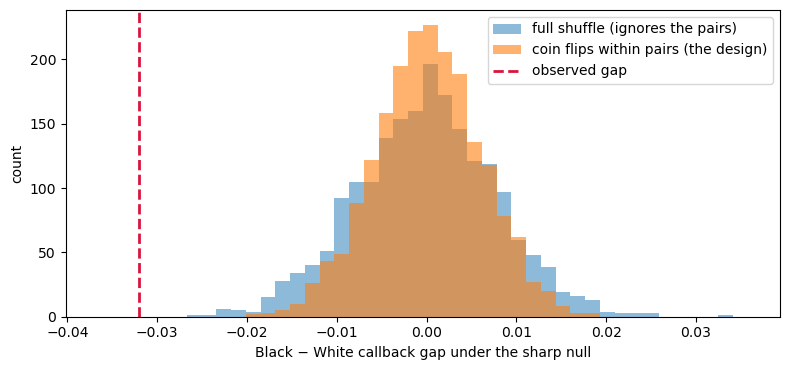

In [9]:
plain_stats = np.empty(n_perm)
for i in range(n_perm):
    shuffled = rng.permutation(black)
    plain_stats[i] = y[shuffled == 1].mean() - y[shuffled == 0].mean()

print(f"sd of placebo gaps, coin flips within pairs : {paired_stats.std():.4f}")
print(f"sd of placebo gaps, full shuffle            : {plain_stats.std():.4f}")

step = 2 / (len(bm) / 2)                          # a placebo gap can only move in steps of 2/2435
bins = (np.arange(-22, 23) * 2 - 0.5) * step      # line the bins up with those steps (avoids a spiky histogram)
plt.figure(figsize=(8, 3.8))
plt.hist(plain_stats,  bins=bins, alpha=0.5, label="full shuffle (ignores the pairs)")
plt.hist(paired_stats, bins=bins, alpha=0.6, label="coin flips within pairs (the design)")
plt.axvline(observed, color="crimson", linestyle="--", linewidth=2, label="observed gap")
plt.xlabel("Black − White callback gap under the sharp null")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

**What you should find:** none of the 2,000 placebo draws produces a gap as large as the observed
3.2 percentage points, under either scheme. Report $p < 1/2000$, not $p = 0$: randomization inference
has a resolution limit set by the number of draws.

The two distributions have different widths. The standard deviation of the placebo gaps is about
**0.006** with coin flips within pairs and about **0.008** with a full shuffle. Compare with the
standard errors in §2: about **0.006** clustered by ad and **0.008** robust. Randomization inference and the regression agree about where the
precision comes from. The next cell shows why.

In [10]:
# one row per pair: did the White résumé get a call? did the Black résumé?
pairs = bm.assign(pair=pair).pivot_table(index="pair", columns="race", values="call").astype(int)
print(pd.crosstab(pairs["w"], pairs["b"], rownames=["White called"], colnames=["Black called"]))

w_only = int(((pairs["w"] == 1) & (pairs["b"] == 0)).sum())
b_only = int(((pairs["w"] == 0) & (pairs["b"] == 1)).sum())
coin_p = stats.binomtest(w_only, w_only + b_only).pvalue
print(f"\npairs where only the White résumé got a call: {w_only}")
print(f"pairs where only the Black résumé got a call: {b_only}")
print(f"chance of a split this lopsided in {w_only + b_only} fair coin flips: p = {coin_p:.1e}")

Black called     0   1
White called          
0             2135  65
1              143  92

pairs where only the White résumé got a call: 143
pairs where only the Black résumé got a call: 65
chance of a split this lopsided in 208 fair coin flips: p = 6.6e-08


**Intuition: where the information lives.** Of the 2,435 pairs, 2,135 got no callback at all and 92
got two. Flipping the names inside those pairs changes nothing. **All of the information is in the 208
pairs where exactly one résumé got a call:** the White résumé in 143 of them, the Black résumé in 65.
Under the sharp null, each of those is a fair coin, and 143 heads in 208 flips almost never happens.
The full shuffle ignores this structure and mixes résumés across employers, so it overstates how much
the gap could move by chance.

In this design, ignoring the pairs made the test *conservative*. Do not count on that. When treatment
is assigned to whole clusters (the hospital example in §6), ignoring the design makes the test *too
optimistic*. Either way the fix is the same: follow the assignment mechanism.

Randomization inference is worth having in your toolkit for three situations that come up
constantly: **few treated clusters** (where cluster-robust errors are badly undersized), **skewed
or bounded outcomes** (a callback rate of 8% is one), and **any design too complicated for a standard
formula** — stratified, matched-pair like this one, or staggered adoption. In every one of these, you
can permute according to the actual assignment mechanism and get an exact test.

---
## §4 "Significant" vs. "not significant" is not a test

**Intuition.** One of the headline findings in the abstract is that a better résumé helps White names
much more than Black names. Table 4 makes the case with two separate tests: the high- vs. low-quality
gap is statistically significant for White names and not significant for Black names.

It is tempting to read that as "the return to quality differs by race." But that sentence is a claim
about the **difference between two effects**, and two separate tests never test it. One estimate can
land just below 0.05 and the other well above, while the two effects are statistically
indistinguishable (Gelman and Stern, 2006). The test that matches the claim is an **interaction**.

In [11]:
# Callback rates (%) by race and résumé quality, as in Table 4, Panel A
rates_pct = 100 * bm.pivot_table(index="race", columns="h", values="call")
print(rates_pct.rename(index={"w": "White names", "b": "Black names"},
                       columns={0: "low quality", 1: "high quality"}).round(2))
print()

# Two separate tests, one per race
for r, label in [("w", "White names"), ("b", "Black names")]:
    sub = bm[bm["race"] == r]
    m = smf.ols("call ~ h", data=sub).fit(cov_type="cluster", cov_kwds={"groups": sub.adid})
    print(f"{label}: return to quality = {m.params['h']:.4f}  (se {m.bse['h']:.4f}, p = {m.pvalues['h']:.3f})")

h            low quality  high quality
race                                  
Black names       6.1900        6.7000
White names       8.5000       10.7900

White names: return to quality = 0.0229  (se 0.0091, p = 0.012)
Black names: return to quality = 0.0052  (se 0.0080, p = 0.520)


### Exercise 4 (5 min)

1. Estimate `call ~ black * h` with standard errors clustered by ad.
2. Write one sentence interpreting each of the four coefficients. (Hint: the intercept is the callback
   rate for White names with low-quality résumés.)
3. Check that the `black:h` coefficient equals
   (Black high − Black low) − (White high − White low) from the table above.
4. Is the return to résumé quality significantly different for Black and White names?

In [12]:
# ---- EXERCISE 4 -------------------------------------------------------------
inter = smf.ols("call ~ black * h", data=bm).fit(cov_type="cluster", cov_kwds={"groups": bm.adid})  # interaction, clustered by ad
print(inter.summary().tables[1])

rates = bm.pivot_table(index="black", columns="h", values="call")
did = (rates.loc[1, 1] - rates.loc[1, 0]) - (rates.loc[0, 1] - rates.loc[0, 0])   # difference in differences by hand
print(f"\nby hand: {did:.4f}    regression: {inter.params['black:h']:.4f}")
# -----------------------------------------------------------------------------

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0850      0.008     10.602      0.000       0.069       0.101
black         -0.0231      0.008     -2.928      0.003      -0.039      -0.008
h              0.0229      0.009      2.514      0.012       0.005       0.041
black:h       -0.0178      0.011     -1.598      0.110      -0.040       0.004

by hand: -0.0178    regression: -0.0178


**What you should find:** a better résumé raises callbacks by **2.3 points** for White names
($p \approx 0.01$) and by **0.5 points** for Black names ($p \approx 0.52$). Taken separately, one
"works" and one does not. But the interaction is **−1.8 points with $p \approx 0.11$**: we cannot
reject that the return to quality is the same for both groups.

**Intuition.** Each estimate carries its own noise, and the difference between two noisy numbers is
noisier than either one. Here the two standard errors are about 0.009 and 0.008, while the standard
error of their difference is about 0.011.

**Connection to pre-analysis plans.** A plan that says *"we will test whether the return to résumé
quality differs by race using the interaction of `black` and `h`, clustered by ad"* commits you to the
test that matches the claim before you know which version produces stars.

To be fair to B&M: the point estimates go in the direction they describe, and they bring other
evidence (Table 4, Panel B, and Table 5). The lesson is about which test supports which sentence, not
a verdict on the paper.

---
## §5 Many subgroups, one file drawer

**Intuition.** Tables 7 and 9 ask whether discrimination is larger or smaller for particular jobs and
employers: ads that list requirements, federal contractors, "Equal Opportunity Employers," and so on.
Each question is reasonable on its own. The problem is the count. Every test at the 5% level carries a
5% chance of a false positive, so if you run enough of them, something comes up "significant" even when
nothing is going on.

This is the file drawer *inside a single project*. Run eight heterogeneity regressions, write up the one
with a star, and leave the other seven in the drawer. Every sentence in the resulting paper would be
true, and its $p$-value would be meaningless.

Below, each row is a separate regression of `call` on `black`, the characteristic, and their
interaction. A positive interaction means the Black–White gap is *smaller* for that kind of job.

In [13]:
characteristics = {
    "req":     "any requirement listed",
    "expreq":  "experience required",
    "comreq":  "communication skills required",
    "educreq": "education required",
    "compreq": "computer skills required",
    "orgreq":  "organization skills required",
    "eoe":     "Equal Opportunity Employer",
    "fed":     "federal contractor",
}

rows = {}
for var, label in characteristics.items():
    sub = bm.dropna(subset=[var])                          # `fed` is missing for some employers
    m = smf.ols(f"call ~ black * {var}", data=sub).fit(cov_type="cluster", cov_kwds={"groups": sub.adid})
    rows[label] = {"black × characteristic": m.params[f"black:{var}"],
                   "std. error": m.bse[f"black:{var}"],
                   "p-value": m.pvalues[f"black:{var}"],
                   "N": len(sub)}

hetero = pd.DataFrame(rows).T
hetero["N"] = hetero["N"].astype(int)
hetero

,black × characteristic,std. error,p-value,N
any requirement listed,0.0329,0.0162,0.0428,4870
experience required,0.0133,0.0124,0.2829,4870
communication skills required,-0.0010,0.0153,0.9488,4870
education required,-0.0158,0.0180,0.3794,4870
computer skills required,0.0050,0.0126,0.6890,4870
organization skills required,0.0285,0.0163,0.0814,4870
Equal Opportunity Employer,-0.0145,0.0132,0.2729,4870
federal contractor,-0.0468,0.0261,0.0724,3102


### Exercise 5 (5 min)

1. If the eight tests were independent and none of these characteristics truly mattered, what is the
   probability that at least one $p$-value falls below 0.05?
2. Adjust the $p$-values with **Bonferroni** and **Holm** using `multipletests`. How many results
   survive at 5%?
3. Suppose you had reported only the row with the smallest $p$-value. Write the sentence you would have
   put in the abstract, and explain what is wrong with it.

In [14]:
# ---- EXERCISE 5 -------------------------------------------------------------
k = len(hetero)
fwer = 1 - 0.95**k                                                               # P(at least one false positive), k independent tests
print(f"chance of at least one p < 0.05 among {k} null tests: {fwer:.3f}")

hetero["Bonferroni p"] = multipletests(hetero["p-value"], method="bonferroni")[1]   # adjusted p-values
hetero["Holm p"]       = multipletests(hetero["p-value"], method="holm")[1]

print(f"significant at 5%:  raw = {(hetero['p-value'] < 0.05).sum()},  "
      f"Bonferroni = {(hetero['Bonferroni p'] < 0.05).sum()},  Holm = {(hetero['Holm p'] < 0.05).sum()}")
hetero.sort_values("p-value")
# -----------------------------------------------------------------------------

chance of at least one p < 0.05 among 8 null tests: 0.337
significant at 5%:  raw = 1,  Bonferroni = 0,  Holm = 0


,black × characteristic,std. error,p-value,N,Bonferroni p,Holm p
any requirement listed,0.0329,0.0162,0.0428,4870,0.3426,0.3426
federal contractor,-0.0468,0.0261,0.0724,3102,0.5790,0.5066
organization skills required,0.0285,0.0163,0.0814,4870,0.6513,0.5066
Equal Opportunity Employer,-0.0145,0.0132,0.2729,4870,1.0000,1.0000
experience required,0.0133,0.0124,0.2829,4870,1.0000,1.0000
education required,-0.0158,0.0180,0.3794,4870,1.0000,1.0000
computer skills required,0.0050,0.0126,0.6890,4870,1.0000,1.0000
communication skills required,-0.0010,0.0153,0.9488,4870,1.0000,1.0000


One more fork in the path: **the model.** B&M estimate these with probits. Same question, same data,
different reasonable model:

In [15]:
probit = smf.probit("call ~ black * req", data=bm).fit(disp=0, cov_type="cluster", cov_kwds={"groups": bm.adid})
print(f"'any requirement listed' interaction:  linear model p = {hetero.loc['any requirement listed', 'p-value']:.3f},"
      f"  probit p = {probit.pvalues['black:req']:.3f}")

'any requirement listed' interaction:  linear model p = 0.043,  probit p = 0.113


**What you should find:** with eight tests, the chance of at least one false positive is about **34%**.
One interaction is significant before adjustment: *any requirement listed*, $p \approx 0.04$. After
Bonferroni or Holm, **none survive** (the smallest adjusted $p$ is about 0.34). And the probit on the
same data puts that same interaction at $p \approx 0.11$. The paper reports all of these interactions
as insignificant, and that is the honest reading.

The abstract sentence from question 3 would be something like *"Employers that list job requirements
discriminate significantly less."* It is true in the sample, it has a star, and it is almost certainly
noise. It only looks significant because seven other tests went unreported, or because of which model
was picked.

**Holm in one line.** Sort the $p$-values. Compare the smallest to $0.05/8$, the next to $0.05/7$, and
so on, and stop at the first one that fails. It controls the same error rate as Bonferroni and is never
less powerful, so there is little reason to use Bonferroni instead.

**Connection to pre-analysis plans.** A plan lists the heterogeneity analyses in advance, fixes the
model, and names the correction. Then a reader knows the eight tests are *all* the tests, and that no
star was chosen after the fact. It also makes a null result worth publishing: "we pre-specified eight
tests of heterogeneity and found none" is a finding, not something for the file drawer.

---
## Takeaways

1. Covariates buy precision, not identification. Center and interact them (Lin), and never control for
   anything measured after randomization.
2. Reproduce before you interpret, and record which version of the paper and which data file you used.
   Headlines are usually sturdier than individual stars.
3. Randomization inference asks how unusual your estimate is among the assignments the experiment could
   have produced, so permute the way the experiment randomized.
4. "Significant here, not significant there" is not evidence of a difference. Test the difference
   directly with an interaction.
5. Count your tests. Enough subgroups will produce a false positive; pre-specify the list, the model,
   and the correction.

---
## §6 Power, MDE, and the design effect

*Preview of next week's lab.*

Everything above is *ex post*. Power analysis is *ex ante*, and it is the single highest-return
hour of work in an experimental project, because it is the only point at which you can still fix
the problem. Power is

$$\text{power} = \Pr(\text{reject } H_0 \mid H_1 \text{ true}).$$

Convention is 0.80: if there really is an effect of the size you specified, you find it 80% of
the time. Read that again — the *convention* accepts a 20% chance of missing a real effect.

Three quantities, and fixing any two pins down the third: **sample size**, **minimum detectable
effect (MDE)**, and **power**. In practice a budget fixes $n$, so you solve for the MDE and ask
whether it is smaller than any effect you would find interesting. If it is not, do not run the
experiment.

In [16]:
power_analysis = smp.TTestIndPower()

# Standardized effect size (Cohen's d) = effect / sd of outcome
n_needed = power_analysis.solve_power(effect_size=0.20, power=0.80, alpha=0.05)
print(f"n per arm to detect d = 0.20 with 80% power: {np.ceil(n_needed):.0f}")

mde_d = power_analysis.solve_power(nobs1=500, power=0.80, alpha=0.05)
print(f"MDE (in sd units) with 500 per arm:          {mde_d:.3f}")

n per arm to detect d = 0.20 with 80% power: 394
MDE (in sd units) with 500 per arm:          0.177


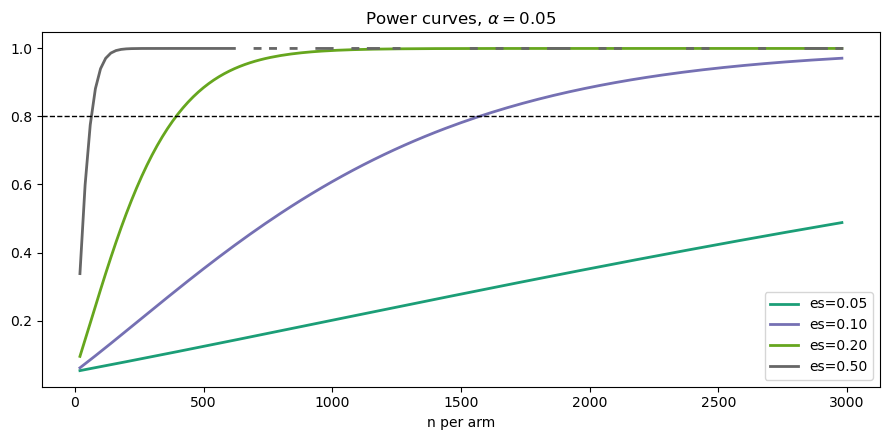

In [17]:
sample_sizes  = np.arange(20, 3000, 20)
effect_sizes  = np.array([0.05, 0.10, 0.20, 0.50])

fig, ax = plt.subplots(figsize=(9, 4.5))
power_analysis.plot_power(dep_var="nobs", nobs=sample_sizes, effect_size=effect_sizes,
                          alpha=0.05, ax=ax, title=r"Power curves, $\alpha = 0.05$")
ax.axhline(0.80, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("n per arm")
plt.tight_layout()
plt.show()

Look at the shape, not the numbers. The curves are steep at small $n$ and flat at large $n$: going
from 100 to 300 per arm buys you a great deal, going from 2,000 to 2,200 buys almost nothing. And
the spacing between the curves is the expensive fact — **halving the effect you want to detect
roughly quadruples the sample you need**, because the MDE scales with $1/\sqrt{n}$.

This is why "we'll just add a few more observations" almost never rescues an underpowered design.

### Trust but verify

`solve_power` inverts a formula. Simulate the experiment and check that the formula tells the
truth.

In [18]:
effect = 0.30                                       # in sd units
n_arm  = int(np.ceil(power_analysis.solve_power(effect_size=effect, power=0.80, alpha=0.05)))

rejections = 0
n_sims = 2_000
for _ in range(n_sims):
    ctrl = rng.normal(0.0,    1.0, n_arm)
    trt  = rng.normal(effect, 1.0, n_arm)
    rejections += stats.ttest_ind(trt, ctrl).pvalue < 0.05

print(f"formula says n = {n_arm} per arm for 80% power")
print(f"simulated power at that n: {rejections / n_sims:.3f}")

formula says n = 176 per arm for 80% power
simulated power at that n: 0.796


### Clustered assignment and the design effect

Here is the mistake that ruins more experiments than any other. Recall the example from
Thursday's notes: 30 hospitals, 15 treated and 15 control, 1,000 patients each. You have 30,000
observations. You do **not** have 30,000 independent observations. Treatment was assigned to
*hospitals*, so you have 30 independent units, and patients within a hospital are correlated.

The correction is the **design effect**:

$$\text{DEFF} = 1 + (m - 1)\rho,$$

where $m$ is the cluster size and $\rho$ is the intra-cluster correlation. Your effective sample
size is $n_{\text{eff}} = n / \text{DEFF}$, and the required $n$ scales up by DEFF.

In [19]:
def design_effect(m, rho):
    return 1 + (m - 1) * rho

rows = []
for rho in [0.0, 0.01, 0.05, 0.10, 0.20]:
    deff = design_effect(m=1000, rho=rho)
    rows.append({"ICC (rho)": rho, "cluster size m": 1000, "DEFF": deff,
                 "effective n (of 30,000)": 30_000 / deff})
pd.DataFrame(rows)

,ICC (rho),cluster size m,DEFF,"effective n (of 30,000)"
0,0.0000,1000,1.0000,"30,000.0000"
1,0.0100,1000,10.9900,"2,729.7543"
2,0.0500,1000,50.9500,588.8126
3,0.1000,1000,100.9000,297.3241
4,0.2000,1000,200.8000,149.4024


Read the row for $\rho = 0.05$ — a completely unremarkable ICC for patients within a hospital.
DEFF is about **51**, so your 30,000 patients are worth roughly **590** independent observations.
Ignoring this does not make your study underpowered; it makes your standard errors about **seven
times too small**, which means your $t$-statistics are seven times too large and your "highly
significant" result is noise.

Notice also what the formula implies about design: because $m$ enters multiplied by $\rho$, adding
more patients *within* existing hospitals has sharply diminishing returns, while adding more
*hospitals* does not. When treatment is clustered, **the number of clusters is what buys power.**

### Where does the ICC come from?

You do not guess it. You estimate it from pilot data or from a comparable published study. The
ANOVA estimator compares between-cluster to within-cluster variance in the outcome.

In [20]:
def icc_anova(data, outcome, cluster):
    '''ANOVA estimator of the intra-cluster correlation.'''
    g = data.groupby(cluster)[outcome]
    k, N = data[cluster].nunique(), len(data)
    msb = (g.count() * (g.mean() - data[outcome].mean())**2).sum() / (k - 1)
    msw = ((data[outcome] - g.transform("mean"))**2).sum() / (N - k)
    m0  = (N - (g.count()**2).sum() / N) / (k - 1)
    return (msb - msw) / (msb + (m0 - 1) * msw)

rho_hat = icc_anova(d, "got", "villnum")
print(f"average village size: {len(d) / d.villnum.nunique():.1f}")
print(f"estimated ICC of `got` across villages: {rho_hat:.3f}")

average village size: 23.7
estimated ICC of `got` across villages: 0.065


### Exercise 6 (6 min)

Suppose you are designing a follow-up to Thornton with a new, cheaper intervention — a text
message reminder instead of cash — and you must assign it **at the village level**, because you
cannot text some people in a village and not others without them talking to each other. (That is
a SUTVA argument, not a logistical one.)

1. Take the control-group mean and standard deviation of `got` from the data as your benchmark.
2. Compute the number of respondents per arm needed to detect a **5 percentage point** increase
   with 80% power, ignoring clustering.
3. Now account for clustering: village size $m = 24$ (the average in Thornton) and the ICC
   `rho_hat` you just estimated. Apply the design effect.
4. Convert to a number of **villages** per arm. Is this study feasible?

In [21]:
# ---- EXERCISE 6 -------------------------------------------------------------
p0 = d.loc[d["any"] == 0, "got"].mean()
sd = d["got"].std()
print(f"control mean = {p0:.3f}, sd of outcome = {sd:.3f}")

mde_abs   = 0.05
effect_d  = mde_abs / sd      # standardize: absolute effect divided by sd

n_naive   = power_analysis.solve_power(effect_size=effect_d, power=0.80, alpha=0.05)  # respondents per arm ignoring clustering
deff      = design_effect(m=24, rho=rho_hat)     # design effect with m = 24 and rho_hat
n_cluster = n_naive * deff                        # respondents per arm accounting for clustering
villages  = n_cluster / 24                        # villages per arm

print(f"\nnaive n per arm      : {np.ceil(n_naive):.0f}")
print(f"design effect        : {deff:.2f}")
print(f"clustered n per arm  : {np.ceil(n_cluster):.0f}")
print(f"villages per arm     : {np.ceil(villages):.0f}")
# -----------------------------------------------------------------------------

control mean = 0.341, sd of outcome = 0.462

naive n per arm      : 1343
design effect        : 2.49
clustered n per arm  : 3347
villages per arm     : 140


**What you should find:** about **1,343** respondents per arm ignoring clustering. The ICC of
`got` across villages is about **0.065**, which with $m = 24$ gives a design effect of roughly
**2.5** — so you actually need about **3,350** respondents per arm, or **140 villages per arm**,
280 in total. Thornton worked with 119 villages. A 5 percentage point effect on this outcome is
not detectable at that scale, and the honest response is to redesign: target a larger effect,
find a covariate that cuts residual variance, stratify on the baseline take-up rate, or accept
that you are running a pilot rather than a test.

Note how modest that ICC is and how much damage it still does. An ICC of 0.065 sounds like
nothing. It more than doubles the sample you need.

That conversation is much cheaper to have now than after two years of fieldwork.

---

## Takeaway from §6

Do the power calculation before the experiment. The MDE scales with $1/\sqrt{n}$ and gets multiplied
by the design effect, and no amount of clever estimation fixes an underpowered design after the fact.